# Paquetes

In [40]:
import numpy as np

import pennylane as qml
from pennylane import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import os
from PIL import Image
from multiprocessing import Pool
import pickle

import matplotlib.pyplot as plt

import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from collections import defaultdict

import re

import random

# Carga de Datos

### Recuento inicial

In [7]:
base_dirs = ["ACDC", "LaFe"]
categories = ["C", "MCD", "MCA", "MU"]

counts = {base: defaultdict(int) for base in base_dirs}
total_counts = defaultdict(int)

for base_dir in base_dirs:
    for subfolder in categories:
        path = "dataset/" + base_dir + "/" + subfolder
        if os.path.exists(path):
            patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
            counts[base_dir][subfolder] = len(patients)
            total_counts[subfolder] += len(patients)

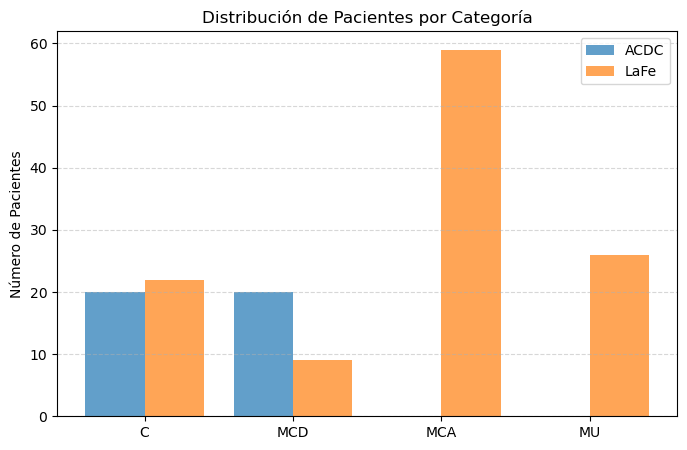

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(categories))

width = 0.4
ax.bar(x, [counts["ACDC"][cat] for cat in categories], width=width, label="ACDC", alpha=0.7)
ax.bar([i + width for i in x], [counts["LaFe"][cat] for cat in categories], width=width, label="LaFe", alpha=0.7)

ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Número de Pacientes")
ax.set_title("Distribución de Pacientes por Categoría")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [9]:
df_count = pd.DataFrame(counts).T 
df_count = pd.DataFrame(counts).T.fillna(0).astype(int)
df_count["Total"] = df_count.sum(axis=1)
df_count.loc["Total"] = df_count.sum(axis=0)

df_count

,C,MCD,MCA,MU,Total
ACDC,20,20,0,0,40
LaFe,22,9,59,26,116
Total,42,29,59,26,156


### Muestreo uniforme

Priorizamos los pacientes de La Fe, usando los del challenge en caso de ausencia de datos

In [34]:
base_dir = "LaFe"
num_samples = 35

data = {category: [] for category in categories}

for subfolder in categories:
    path = "dataset/" + base_dir + "/" + subfolder
    if os.path.exists(path):
        patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
        sampled_patients = random.sample(patients, min(num_samples, len(patients)))
        data[subfolder].extend([base_dir+"/"+subfolder+"/"+patient.replace(".nii.gz", "") for patient in sampled_patients])

base_dir = "ACDC"
for subfolder in categories:
    path = "dataset/" + base_dir + "/" + subfolder
    if os.path.exists(path):
        patients = {f for f in os.listdir(path) if f.endswith(".nii.gz")}
        sampled_patients = random.sample(patients, min(num_samples-len(data[subfolder]), len(patients)))
        data[subfolder].extend([base_dir+"/"+subfolder+"/"+patient.replace(".nii.gz", "") for patient in sampled_patients])

C:\Users\mateo\AppData\Local\Temp\ipykernel_20628\344377081.py:10: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_patients = random.sample(patients, min(num_samples, len(patients)))
C:\Users\mateo\AppData\Local\Temp\ipykernel_20628\344377081.py:18: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  sampled_patients = random.sample(patients, min(num_samples-len(data[subfolder]), len(patients)))


In [35]:
all_data = [(p, cat) for cat, patients in data.items() for p in patients]

df = pd.DataFrame(all_data, columns=["patient", "category"])

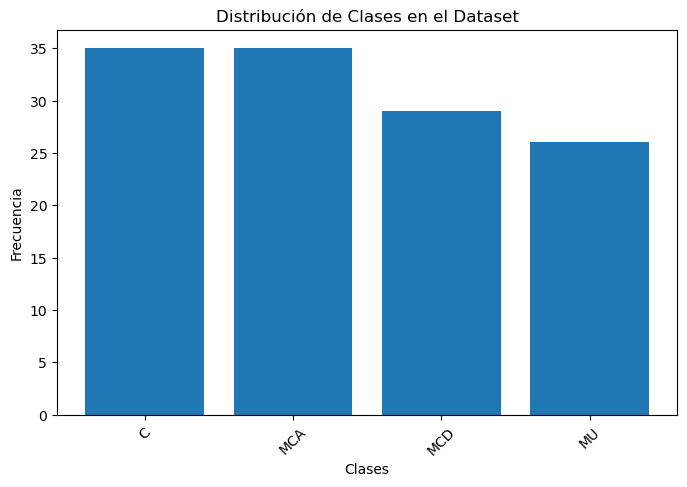

In [36]:
class_counts = df["category"].value_counts()

# Graficar el histograma
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

# Personalizar el gráfico
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.title("Distribución de Clases en el Dataset")
plt.xticks(rotation=45)

# Mostrar el histograma
plt.show()

## Partición

In [37]:
train, temp = train_test_split(df, test_size=0.3, stratify=df["category"], random_state=42)
val, test = train_test_split(temp, test_size=1/3, stratify=temp["category"], random_state=42)

In [38]:
train

,patient,category
27,ACDC/C/patient066_4d_ES11,C
16,LaFe/C/C_21,C
109,LaFe/MU/9055,MU
100,LaFe/MU/9065,MU
57,ACDC/MCD/patient008_4d_ES13,MCD
...,...,...
24,ACDC/C/patient063_4d_ES16,C
113,LaFe/MU/9041,MU
65,LaFe/MCA/9056,MCA
47,ACDC/MCD/patient019_4d_ES11,MCD


## Train

In [ ]:
extract_dir = "results/imagenes"

array_shape = (32, 32)

In [63]:
image_labels_tr = []
image_tr=[]

for _, row in train.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_tr.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_tr.append(img_array)

image_tr = np.array(image_tr, dtype=np.int8)

train_imgs_tf = (image_tr / 255)*np.pi
df_tr = pd.DataFrame(image_labels_tr)

print(df_tr.head(10))
print(df_tr.shape)

print(train_imgs_tf.shape)

with open("data/train_imgs_tf.pkl", "wb") as file:
    pickle.dump(train_imgs_tf, file)

with open("data/df_tr.pkl", "wb") as file:
    pickle.dump(df_tr, file)

         patient_name class       image_type img_number
0  patient066_4d_ES11     C  circunferencial         00
1  patient066_4d_ES11     C  circunferencial         01
2  patient066_4d_ES11     C  circunferencial         02
3  patient066_4d_ES11     C  circunferencial         03
4  patient066_4d_ES11     C  circunferencial         04
5  patient066_4d_ES11     C  circunferencial         05
6  patient066_4d_ES11     C  circunferencial         06
7  patient066_4d_ES11     C  circunferencial         07
8  patient066_4d_ES11     C  circunferencial         08
9  patient066_4d_ES11     C  circunferencial         09
(2784, 4)
(2784, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


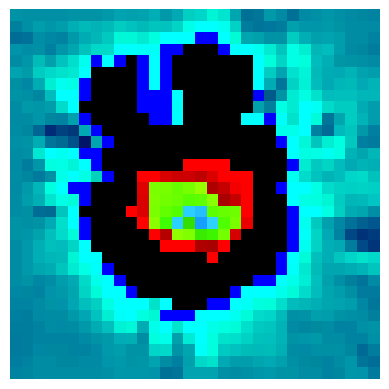

In [64]:
plt.imshow(train_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Validation

In [65]:
image_labels_val = []
image_val=[]

for _, row in val.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_val.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_val.append(img_array)

image_val = np.array(image_val, dtype=np.int8)

val_imgs_tf = (image_val / 255)*np.pi
df_val = pd.DataFrame(image_labels_val)

print(df_val.head(10))
print(df_val.shape)

print(val_imgs_tf.shape)

with open("data/val_imgs_tf.pkl", "wb") as file:
    pickle.dump(val_imgs_tf, file)

with open("data/df_val.pkl", "wb") as file:
    pickle.dump(df_val, file)

         patient_name class       image_type img_number
0  patient064_4d_ES12     C  circunferencial         00
1  patient064_4d_ES12     C  circunferencial         01
2  patient064_4d_ES12     C  circunferencial         02
3  patient064_4d_ES12     C  circunferencial         03
4  patient064_4d_ES12     C  circunferencial         04
5  patient064_4d_ES12     C  circunferencial         05
6  patient064_4d_ES12     C  circunferencial         06
7  patient064_4d_ES12     C  circunferencial         07
8  patient064_4d_ES12     C  circunferencial         08
9  patient064_4d_ES12     C  circunferencial         09
(800, 4)
(800, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


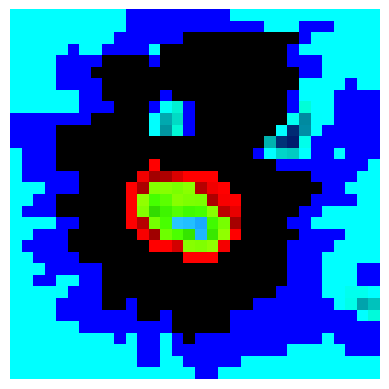

In [66]:
plt.imshow(val_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Test

In [67]:
image_labels_test = []
image_test=[]

for _, row in test.iterrows():
    folder_path = row["patient"]
    category = row["category"]
    patient_name = os.path.basename(folder_path).split("/")[-1]
    path = extract_dir+"/"+folder_path
    for type in os.listdir(path):
        path = extract_dir+"/"+folder_path+"/"+type
        for img_path in os.listdir(path):
            path = extract_dir+"/"+folder_path+"/"+type+"/"+img_path
            with Image.open(path) as img:
                img = img.convert('RGB')
                img = img.resize(array_shape)
                img_array = np.array(img)

            img_number = re.search(r"_(\d{2})_", img_path).group(1)

            image_labels_test.append({
                "patient_name": patient_name,
                "class": category,
                "image_type": type,
                "img_number": img_number,
            })

            image_test.append(img_array)

image_test = np.array(image_test, dtype=np.int8)

test_imgs_tf = (image_test / 255)*np.pi
df_test = pd.DataFrame(image_labels_test)

print(df_test.head(10))
print(df_test.shape)

print(test_imgs_tf.shape)

with open("data/test_imgs_tf.pkl", "wb") as file:
    pickle.dump(test_imgs_tf, file)

with open("data/df_testl.pkl", "wb") as file:
    pickle.dump(df_test, file)

         patient_name class       image_type img_number
0  patient001_4d_ES12   MCD  circunferencial         00
1  patient001_4d_ES12   MCD  circunferencial         01
2  patient001_4d_ES12   MCD  circunferencial         02
3  patient001_4d_ES12   MCD  circunferencial         03
4  patient001_4d_ES12   MCD  circunferencial         04
5  patient001_4d_ES12   MCD  circunferencial         05
6  patient001_4d_ES12   MCD  circunferencial         06
7  patient001_4d_ES12   MCD  circunferencial         07
8  patient001_4d_ES12   MCD  circunferencial         08
9  patient001_4d_ES12   MCD  circunferencial         09
(416, 4)
(416, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


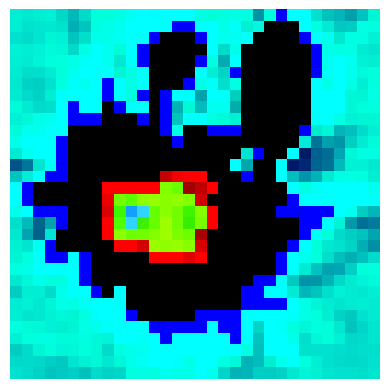

In [68]:
plt.imshow(test_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Estadísticas de los datos

In [69]:
def plot_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_classes, counts)
    plt.title(f'Class Distribution in {dataset_name} Set')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()


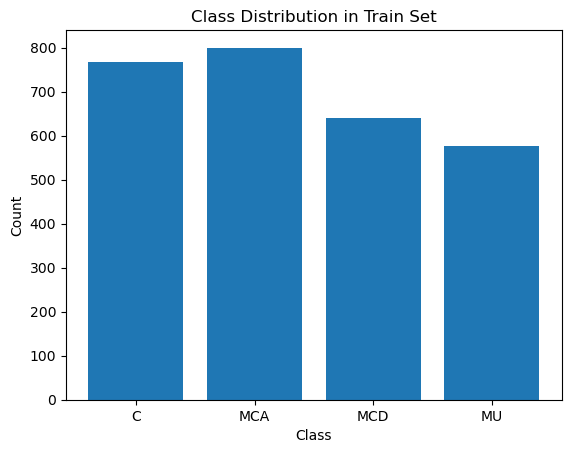

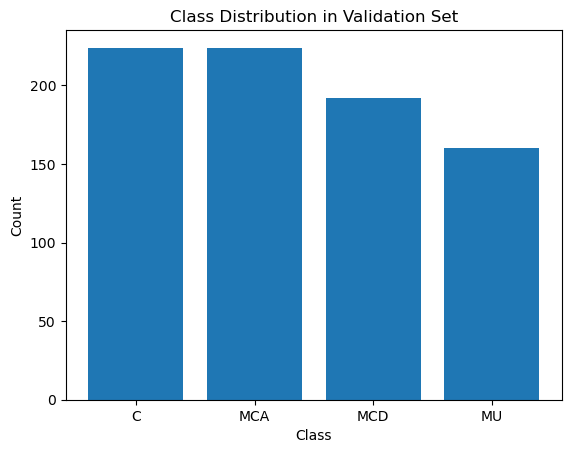

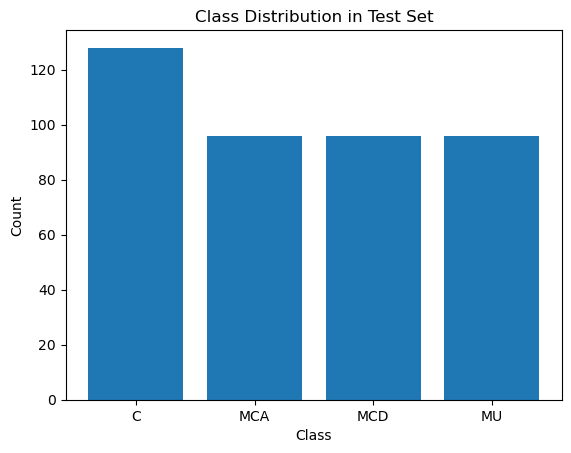

In [70]:
plot_class_distribution(df_tr["class"], 'Train')
plot_class_distribution(df_val["class"], 'Validation')
plot_class_distribution(df_test["class"], 'Test')

# Circuitos Cuánticos

In [11]:
n_qubits = 12
graphs = {
    "closed-nn" : [[0,6], [6,9], [9,3], [3,0], [0,1], [6,7], [9,10], [3,4], [1,7], [7,10], [10,4], [4,1], [1,2], [7,8], [10,11], [4,5], [2,8], [8,11], [11,5], [5,2]],
    "open-nn": [[0,1],[1,2],[2,8],[8,7],[7,6],[6,9],[9,10],[10,11],[11,5],[5,4],[4,3]]
}

dev = qml.device('default.qubit', wires=n_qubits)

## Closed

In [12]:
@qml.qnode(dev, interface="autograd")
def closed_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["closed-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Opened

In [13]:
@qml.qnode(dev, interface="autograd")
def open_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["open-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Quanvolución

In [14]:
def quanv(idx, image, folder):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((array_shape[0]-1, array_shape[1]-1, 24))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, array_shape[0]-1, 1):
        for k in range(0, array_shape[1]-1, 1):
            a0=image[j, k, 0]
            a1=image[j, k, 1]
            a2=image[j, k, 2]
            
            b0=image[j, k + 1, 0]
            b1=image[j, k + 1, 1]
            b2=image[j, k + 1, 2]
            
            c0=image[j + 1, k, 0]
            c1=image[j + 1, k, 1]
            c2=image[j + 1, k, 2]
            
            d0=image[j + 1, k + 1, 0]
            d1=image[j + 1, k + 1, 1]
            d2=image[j + 1, k + 1, 2]

            q1_results = closed_circuit( # circuit 2
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )
            q2_results = open_circuit( # circuit 3
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )

            for c in range(12):
                out[j, k, c] = q1_results[c]
            for c in range(12): 
                out[j, k, c+12] = q2_results[c]

    if folder=="train":
        with open(f"quantum_4/train/train_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="validation":
        with open(f"quantum_4/validation/val_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="test":
        with open(f"quantum_4/test/test_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)

In [ ]:
if __name__=="__main__":
    num_cores = os.cpu_count() - 2
    
    pool_tr = Pool(processes=num_cores)
    pool_val = Pool(processes=num_cores)
    pool_test = Pool(processes=num_cores)
    
    # PROCCESS TRAIN DATA SET
    print("Quantum pre-processing of train images")
    for idx, img in enumerate(train_imgs_tf):
        pool_tr.apply_async(quanv, args=(idx,img,"train"))
    pool_tr.close()
    pool_tr.join()

    # PROCCESS VALIDATION DATA SET
    print("Quantum pre-processing of validation images")
    for idx, img in enumerate(val_imgs_tf):
        pool_val.apply_async(quanv, args=(idx,img,"validation"))
    pool_val.close()
    pool_val.join()
    
    # PROCCESS TEST DATA SET
    print("Quantum pre-processing of test images")
    for idx, img in enumerate(test_imgs_tf):
        pool_test.apply_async(quanv, args=(idx,img,"test"))
    pool_test.close()
    pool_test.join()

Quantum pre-processing of train images


In [14]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [17]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [18]:
q_train_images = load_data_to_cpu("quantum_4/train/train_{}.pkl", len(train_imgs_tf))
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum_4/validation/val_{}.pkl", len(val_imgs_tf))
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum_4/test/test_{}.pkl", len(test_imgs_tf))
print(q_test_images.shape)

q_train_images_gpu = cpu_to_gpu(q_train_images)
print(q_train_images_gpu.shape)

q_val_images_gpu = cpu_to_gpu(q_val_images)
print(q_val_images_gpu.shape)

q_test_images_gpu = cpu_to_gpu(q_test_images)
print(q_test_images_gpu.shape)

(10957, 31, 31, 24)
(800, 31, 31, 24)
(1120, 31, 31, 24)
(10957, 31, 31, 24)
(800, 31, 31, 24)
(1120, 31, 31, 24)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


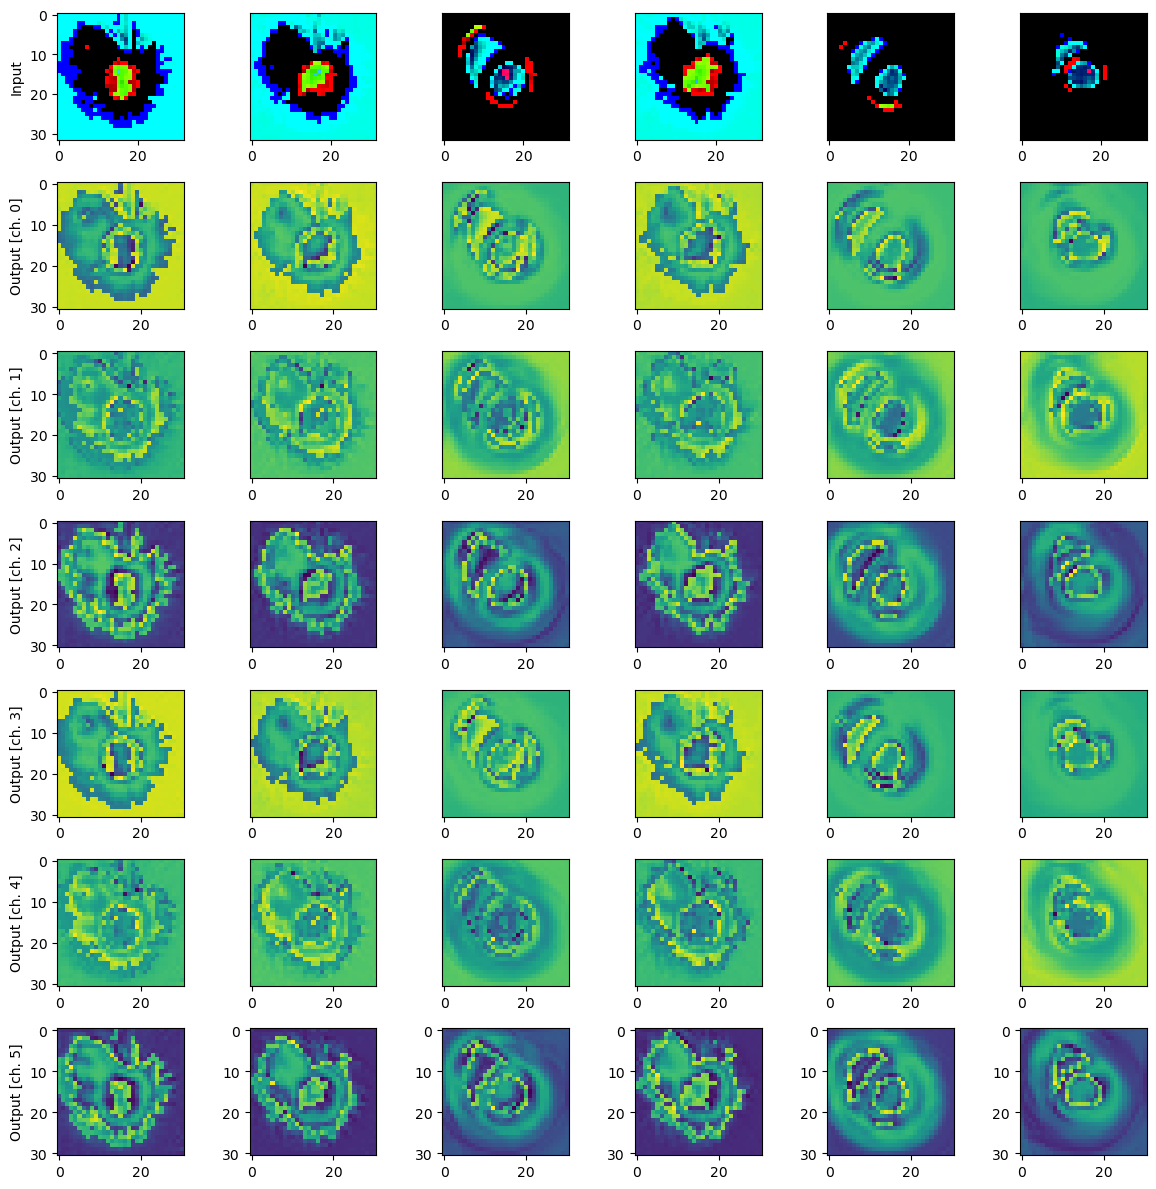

In [19]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, : ,c])

plt.tight_layout()
plt.show()

# Modelos básicos

In [20]:
def cnn(learning_rate, activation, dropout):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv3D(24, (2,2,3), strides = 1, activation='relu', input_shape=(array_shape[0],array_shape[1],3,1)), #Convolucion que sustituye a la cuantica
        keras.layers.Reshape((31, 31, 24)),
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, padding="same"),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling2D(pool_size=3),
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, trainable=True, padding="same"),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def qcnn(learning_rate, activation, dropout):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, input_shape=(array_shape[0]-1,array_shape[1]-1,24), padding="same"),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling2D(pool_size=3),
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, padding="same"),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [21]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images shape: {q_train_images.shape}')
print(f'q_val_images shape: {q_val_images.shape}')
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

q_train_images shape: (10957, 31, 31, 24)
q_val_images shape: (800, 31, 31, 24)
train_imgs_tf shape: (10957, 32, 32, 3)
val_imgs_tf shape: (800, 32, 32, 3)


In [22]:
train_imgs_tf=train_imgs_tf.reshape((10957,32,32,3,1))
val_imgs_tf=val_imgs_tf.reshape((800,32,32,3,1))

In [23]:
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

train_imgs_tf shape: (10957, 32, 32, 3, 1)
val_imgs_tf shape: (800, 32, 32, 3, 1)


In [46]:
Encoder=OneHotEncoder(sparse=False)

train_labels=Encoder.fit_transform(df_tr["class"].values.reshape(-1, 1))
val_labels=Encoder.fit_transform(df_val["class"].values.reshape(-1, 1))
test_labels=Encoder.fit_transform(df_test["class"].values.reshape(-1, 1))

Encoder.categories_

[array(['C', 'D', 'H', 'VI'], dtype=object)]

## QCNN

In [38]:
q_model = qcnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)

q_model.summary()

/home/maloto3/anaconda3/envs/quantum/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 32)     │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        12,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,164 (78.77 KB)

 Trainable params: 20,100 (78.52 KB)

 Non-trainable params: 64 (256.00 B)

In [39]:
q_history = q_model.fit(
    q_train_images_gpu,
    train_labels,
    validation_data=(q_val_images_gpu, val_labels),
    batch_size=128,
    epochs=300,
    verbose=2
)

Epoch 1/300
86/86 - 8s - 87ms/step - accuracy: 0.3337 - loss: 1.5182 - val_accuracy: 0.2700 - val_loss: 1.3896
Epoch 2/300
86/86 - 1s - 11ms/step - accuracy: 0.3877 - loss: 1.2979 - val_accuracy: 0.2975 - val_loss: 1.3664
Epoch 3/300
86/86 - 1s - 11ms/step - accuracy: 0.4321 - loss: 1.2543 - val_accuracy: 0.3350 - val_loss: 1.3288
Epoch 4/300
86/86 - 1s - 11ms/step - accuracy: 0.4523 - loss: 1.2178 - val_accuracy: 0.3750 - val_loss: 1.3048
Epoch 5/300
86/86 - 1s - 13ms/step - accuracy: 0.4629 - loss: 1.1937 - val_accuracy: 0.3713 - val_loss: 1.2928
Epoch 6/300
86/86 - 1s - 11ms/step - accuracy: 0.4798 - loss: 1.1659 - val_accuracy: 0.4325 - val_loss: 1.2441
Epoch 7/300
86/86 - 1s - 13ms/step - accuracy: 0.5000 - loss: 1.1387 - val_accuracy: 0.3837 - val_loss: 1.2826
Epoch 8/300
86/86 - 1s - 12ms/step - accuracy: 0.5171 - loss: 1.1088 - val_accuracy: 0.4013 - val_loss: 1.2589
Epoch 9/300
86/86 - 1s - 12ms/step - accuracy: 0.5227 - loss: 1.0978 - val_accuracy: 0.3875 - val_loss: 1.2667
E

In [40]:
q_predictions=q_model.predict(q_test_images_gpu)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


AUC for class 1: 0.589664296207265
AUC for class 2: 0.6709617332175926
AUC for class 3: 0.6615898437500001
AUC for class 4: 0.8601526331018517
Mean AUC: 0.6955921265691773
F1_Score: 0.3870967741935484
ACC: 0.33214285714285713


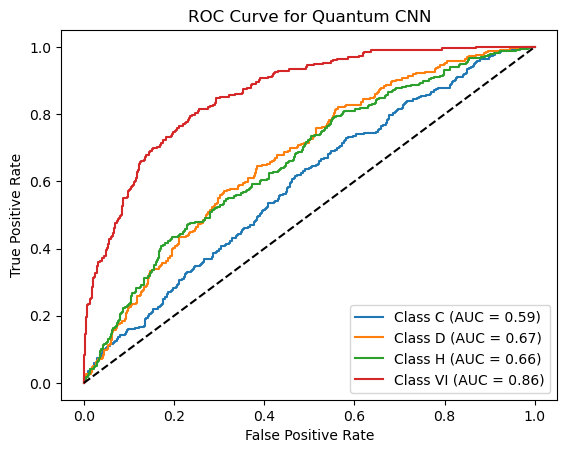

In [61]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
import numpy as np

auc_scores = []
for i in range(test_labels.shape[1]):
    auc = roc_auc_score(test_labels[:, i], q_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels, np.round(q_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels, np.round(q_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels[:, i], q_predictions[:, i])

# Opcional: si quieres graficar las curvas ROC
import matplotlib.pyplot as plt

for i in range(test_labels.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Quantum CNN')
plt.legend(loc='best')
plt.show()


## CNN

In [42]:
c_model = cnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)

c_model.summary()

/home/maloto3/anaconda3/envs/quantum/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_1 (Conv3D)               │ (None, 31, 31, 1, 24)  │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 31, 31, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 31, 31, 32)     │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │        12,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,476 (79.98 KB)

 Trainable params: 20,412 (79.73 KB)

 Non-trainable params: 64 (256.00 B)

In [43]:
c_history = c_model.fit(
    cpu_to_gpu(train_imgs_tf),
    train_labels,
    validation_data=(cpu_to_gpu(val_imgs_tf), val_labels),
    batch_size=128,
    epochs=300,
    verbose=2,
)

Epoch 1/300
86/86 - 7s - 84ms/step - accuracy: 0.3339 - loss: 1.5377 - val_accuracy: 0.3038 - val_loss: 1.3765
Epoch 2/300
86/86 - 1s - 9ms/step - accuracy: 0.4082 - loss: 1.2861 - val_accuracy: 0.3288 - val_loss: 1.3420
Epoch 3/300
86/86 - 1s - 10ms/step - accuracy: 0.4274 - loss: 1.2483 - val_accuracy: 0.3487 - val_loss: 1.3335
Epoch 4/300
86/86 - 1s - 9ms/step - accuracy: 0.4451 - loss: 1.2243 - val_accuracy: 0.3675 - val_loss: 1.2960
Epoch 5/300
86/86 - 2s - 21ms/step - accuracy: 0.4687 - loss: 1.1881 - val_accuracy: 0.3587 - val_loss: 1.3120
Epoch 6/300
86/86 - 1s - 9ms/step - accuracy: 0.4892 - loss: 1.1598 - val_accuracy: 0.4100 - val_loss: 1.2403
Epoch 7/300
86/86 - 1s - 9ms/step - accuracy: 0.4987 - loss: 1.1432 - val_accuracy: 0.4250 - val_loss: 1.2511
Epoch 8/300
86/86 - 1s - 9ms/step - accuracy: 0.5072 - loss: 1.1255 - val_accuracy: 0.4162 - val_loss: 1.2278
Epoch 9/300
86/86 - 1s - 9ms/step - accuracy: 0.5184 - loss: 1.1127 - val_accuracy: 0.3787 - val_loss: 1.2588
Epoch 1

In [44]:
c_predictions=c_model.predict(test_imgs_tf)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


AUC for class 1: 0.6090578258547008
AUC for class 2: 0.6844030309606483
AUC for class 3: 0.65151953125
AUC for class 4: 0.8575303819444444
Mean AUC: 0.7006276925024484
F1_Score: 0.38906088751289986
ACC: 0.3366071428571429


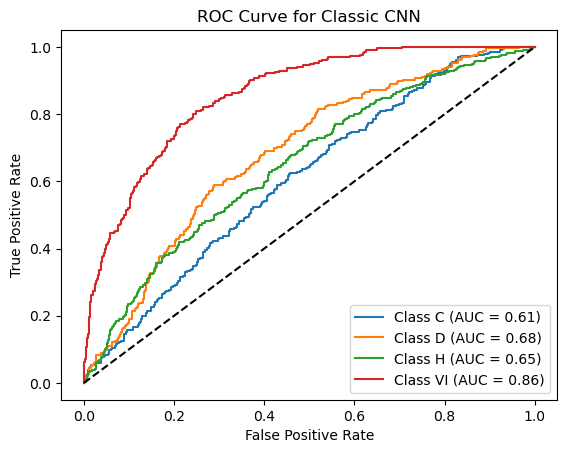

In [62]:
auc_scores = []
for i in range(test_labels.shape[1]):
    auc = roc_auc_score(test_labels[:, i], c_predictions[:, i])
    auc_scores.append(auc)
    print(f"AUC for class {i+1}:", auc)

# Promedio del AUC:
mean_auc = np.mean(auc_scores)
print("Mean AUC:", mean_auc)

# F1_Score y Accuracy (calculado como promedio micro):
f1 = f1_score(test_labels, np.round(c_predictions), average='micro')
print('F1_Score:', f1)

# Accuracy:
acc = accuracy_score(test_labels, np.round(c_predictions))
print('ACC:', acc)

# Si quieres también obtener las curvas ROC para cada clase:
fpr = dict()
tpr = dict()
thresholds = dict()

for i in range(test_labels.shape[1]):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels[:, i], c_predictions[:, i])

# Opcional: si quieres graficar las curvas ROC
import matplotlib.pyplot as plt

for i in range(test_labels.shape[1]):
    plt.plot(fpr[i], tpr[i], label=f'Class {Encoder.categories_[0][i]} (AUC = {auc_scores[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classic CNN')
plt.legend(loc='best')
plt.show()


# Robustez de los resultados

In [63]:
num_modelos= 30
classic_accuracies=[]
quantum_accuracies=[]

In [64]:
epochs=400

In [66]:
for _ in range(num_modelos):
    c_model  = cnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)
    
    c_history = c_model.fit(
    cpu_to_gpu(train_imgs_tf),
    train_labels,
    validation_data=(cpu_to_gpu(val_imgs_tf), val_labels),
    batch_size=256,
    epochs=epochs,
    verbose=0)

    classic_accuracies.append(c_history.history['val_accuracy'])

In [67]:
for _ in range(num_modelos):
    q_model  = qcnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)
    
    q_history = q_model.fit(
    q_train_images_gpu,
    train_labels,
    validation_data=(q_val_images_gpu, val_labels),
    batch_size=256,
    epochs=epochs,
    verbose=0)

    quantum_accuracies.append(q_history.history['val_accuracy'])

In [70]:
# Convert lists to numpy arrays for easier manipulation
q_accs = np.array(quantum_accuracies)
c_accs = np.array(classic_accuracies)

q_accs.shape
c_accs.shape 

(30, 400)

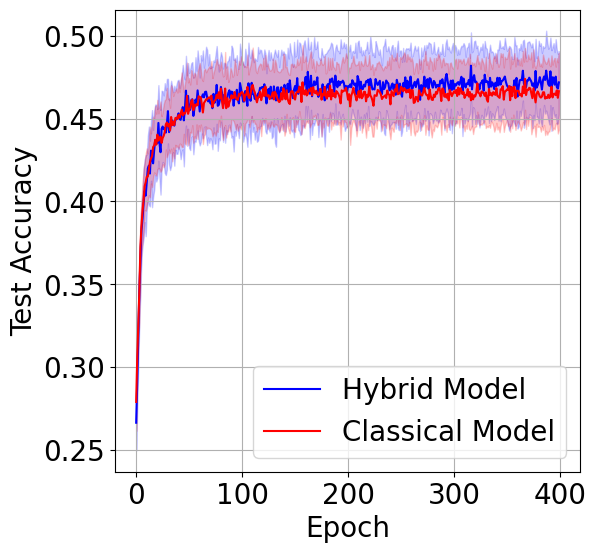

In [72]:
plt.rcParams.update({'font.size': 20})

# Calculate mean and standard deviation
q_mean = np.mean(q_accs, axis=0)
q_std = np.std(q_accs, axis=0)
c_mean = np.mean(c_accs, axis=0)
c_std = np.std(c_accs, axis=0)

# Plot the results
epochs = np.arange(400)
plt.figure(figsize=(6, 6))

# Quantum model plot
plt.plot(epochs, q_mean, label='Hybrid Model', color='blue')
plt.fill_between(epochs, q_mean - q_std, q_mean + q_std, color='blue', alpha=0.2)

# Classical model plot
plt.plot(epochs, c_mean, label='Classical Model', color='red')
plt.fill_between(epochs, c_mean - c_std, c_mean + c_std, color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()